<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/10_gradient_descent_code_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from scipy.stats import probplot
from sklearn.datasets import make_regression


In [4]:
X,y=make_regression(n_samples=100, n_features=1, n_targets=1, n_informative=1, noise=42)

In [116]:
df=pd.DataFrame(
    {
        "X":X.ravel(),
        "y":y
    }
)
df.head()

,X,y
0,-1.136063,-79.453421
1,0.007730,33.000836
2,-0.077325,-29.688161
3,-1.123048,-102.160674
4,-0.660908,8.686989


In [6]:
y

array([ -79.4534214 ,   33.0008355 ,  -29.68816138, -102.16067449,
          8.68698917, -209.28896168,   95.42329615, -116.01366326,
         30.34675135,   30.33628226,  198.74662806,   41.74012864,
        157.04620993,   62.70019581,  -10.53353134,  -10.37662395,
       -168.9921466 ,  -54.84475481,  -69.55421547,   98.67547527,
         49.77076927,  -28.16251059,   94.23534903,  -70.59013941,
        -84.49121696,   40.59599295,  -12.75772446,  -44.55609693,
        -99.44350793, -184.91596864,   17.27330741,  -46.064991  ,
        183.37550568,   23.41889065,   48.18438914,  250.48897317,
       -102.00337642,    7.81809361,  160.65913002,  -57.25450539,
        -15.23379808,  -77.85801867,  -60.55369352,  -14.37254324,
         57.54341306,  -74.99078728,    9.85905843,   64.96570573,
       -125.47583903,  246.33666462,   57.80321944,  -82.51139555,
         40.0282632 ,  -60.10013481,  -68.94279075,   16.54822518,
        -10.12819496,   52.15459875,  119.12197004,   57.86099

In [9]:
X.ndim

2

In [10]:
y.ndim

1

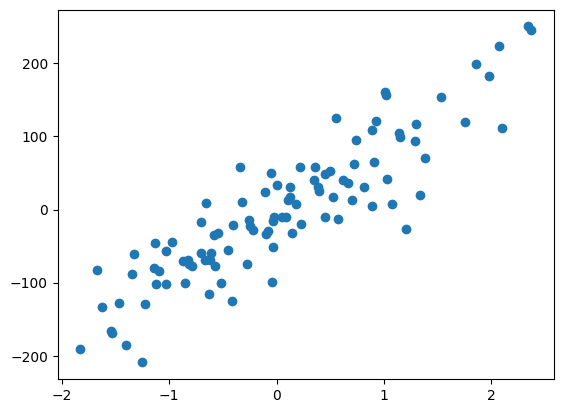

In [174]:
plt.scatter(X.ravel(),y)

<Axes: ylabel='Density'>

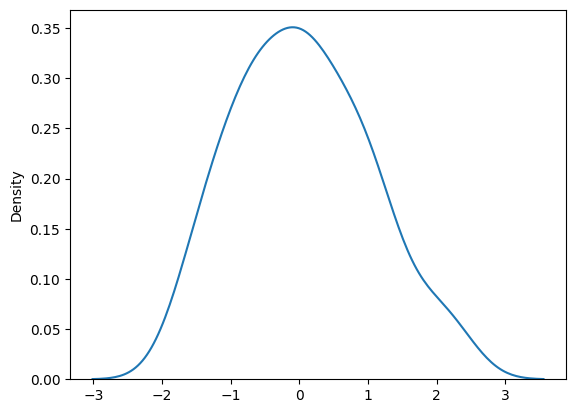

In [175]:
sns.kdeplot(X.ravel())

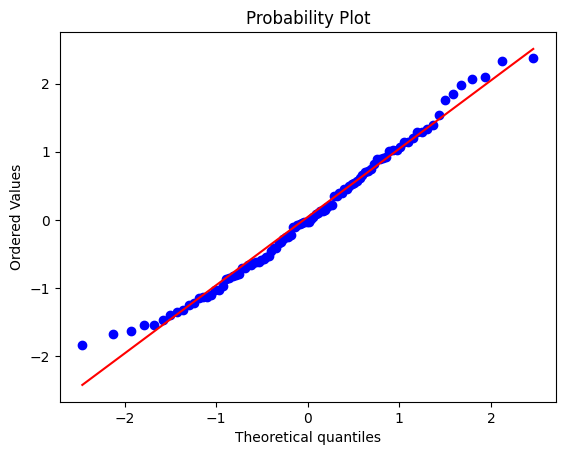

In [19]:
probplot(x=X.flatten(),plot=plt)
plt.show()

In [188]:
lr=LinearRegression()
lr.fit(X,y)

LinearRegression()

In [189]:
y_pred=lr.predict(X)

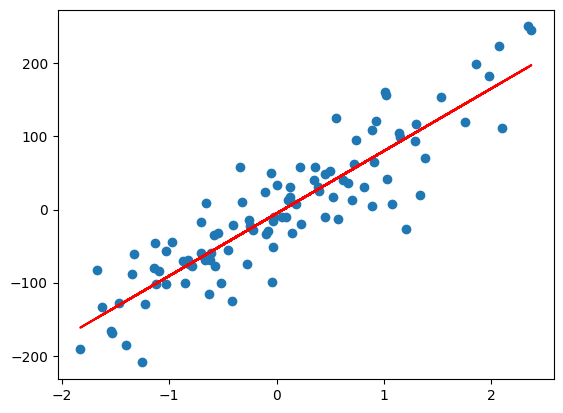

In [190]:
plt.scatter(X,y)
plt.plot(X,y_pred, color="red")

In [191]:
lr.coef_

array([85.56000343])

In [192]:
lr.intercept_

np.float64(-5.363222867942604)

value of Interceptor -5.337979564077573
value of Slope 85


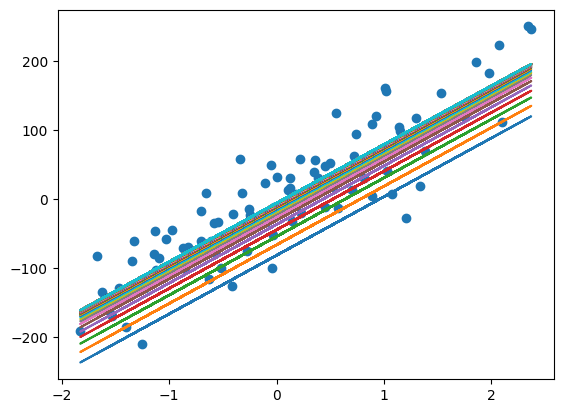

In [193]:
m=85
b=-100
lrate=0.001
epochs=100

for i in range(epochs):
  loss_slope=-2* np.sum(y-m*X.ravel()-b)
  b = b-(lrate*loss_slope)
  y_pred=(m*X+b).reshape(X.shape)
  plt.plot(X.ravel(),y_pred)

print("value of Interceptor",b)
print("value of Slope",m)

plt.scatter(X,y)





In [194]:
X.shape

(100, 1)

value of Interceptor -5.337979564077573
value of Slope 85


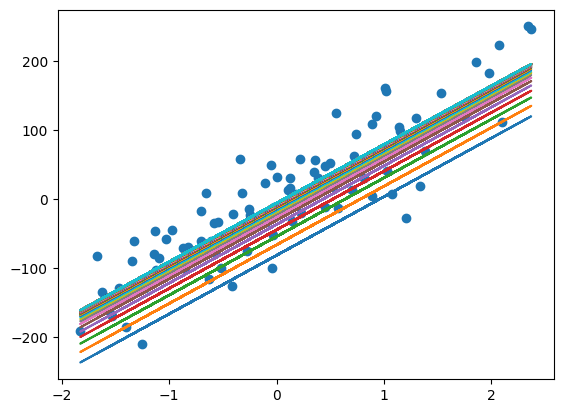

In [195]:
m=85
b=-100
lrate=0.001
epochs=100

for i in range(epochs):
  loss_slope=-2* np.sum(y-m*X.ravel()-b)
  b = b-(lrate*loss_slope)
  y_pred=(m*X.ravel()+b).reshape(X.shape)
  plt.plot(X.ravel(),y_pred)

print("value of Interceptor",b)
print("value of Slope",m)

plt.scatter(X,y)





**Using Python Class**

In [196]:
class SGDReg:

  def __init__(self,epochs,lrate):
    self.epochs=epochs
    self.lrate=lrate
    self.m=85
    self.b=-100

  def fit(self,X,y):

    for i in range(self.epochs):
      loss_slope = -2*np.sum(y-self.m*X.ravel()-self.b)
      self.b = self.b-(self.lrate*loss_slope)


    print("value of inteceptor: {}".format(self.b))

  def predict(self,X):
    return (self.m*X+self.b).reshape(X.shape)

In [197]:
lr2=SGDReg(100,0.001)

In [198]:
lr2.fit(X,y)

value of inteceptor: -5.337979564077573


In [199]:
y_pred2=lr2.predict(X)

In [200]:
X.ravel()

array([-1.1360626 ,  0.00772987, -0.07732496, -1.12304754, -0.66090761,
       -1.24900325,  0.74254654, -0.62983847,  0.81517253,  0.12837008,
        1.85315332,  1.02354786,  1.01996412,  0.71607108,  0.45046612,
        0.0466086 , -1.53162685, -0.44874876, -0.66534201,  1.1464972 ,
       -0.05147976, -0.21842489,  1.29096226, -0.87161621, -1.09736331,
        0.61862972,  0.5673879 , -0.96878368, -0.04119089, -1.39638634,
        0.5227314 , -1.12959201,  1.97447815, -0.1063164 ,  0.45060405,
        2.33610602, -1.02463661,  1.07528954,  1.00723021, -1.02435026,
       -0.03610979, -0.56974688, -1.32474182, -0.25428253,  0.35473669,
       -0.81319196, -0.31864886,  0.90456569, -0.41525731,  2.36939132,
        0.21492019, -1.67439157,  0.35227416, -0.61225657, -0.82529348,
        0.12545792,  0.08851964,  0.49710526,  1.75781213, -0.33770976,
       -1.82653433,  1.29341787,  0.66274904, -0.27479109,  0.39302142,
       -0.70208256, -0.02786196, -1.62512832,  0.54867194, -0.62

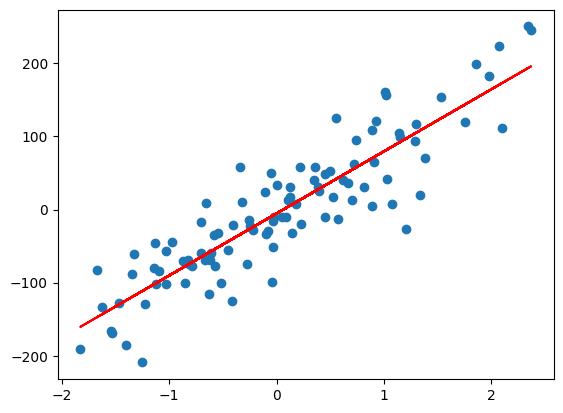

In [201]:
plt.scatter(X,y)
plt.plot(X.ravel(),y_pred2,color="red")

In [202]:
X.ravel().ndim

1

In [203]:
y_pred2.ndim

2

In [204]:
y_pred3=lr2.predict(np.array([[0.007730]]))


In [205]:
y.shape

(100,)

In [173]:
y_pred2.shape

(100, 1)